<a href="https://colab.research.google.com/github/MintzyG/DataAnalytics/blob/main/DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3

conn = sqlite3.connect('/content/f1db.db')
print("Database 'f1db.db' opened successfully.")

Database 'f1db.db' opened successfully.


In [7]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

if tables:
  print("Tables available in the database:")
  for i, table_name in enumerate(tables):
    print(f"{i+1}. {table_name[0]}")
    cursor.execute("")
else:
  print("No tables found in the database.")



Tables available in the database:
1. continent
2. country
3. driver
4. driver_family_relationship
5. constructor
6. constructor_chronology
7. chassis
8. engine_manufacturer
9. engine
10. tyre_manufacturer
11. entrant
12. circuit
13. circuit_layout
14. grand_prix
15. season
16. season_entrant
17. season_entrant_constructor
18. season_entrant_chassis
19. season_entrant_engine
20. season_entrant_tyre_manufacturer
21. season_entrant_driver
22. season_constructor
23. season_engine_manufacturer
24. season_tyre_manufacturer
25. season_driver
26. season_driver_standing
27. season_constructor_standing
28. race
29. race_data
30. race_driver_standing
31. race_constructor_standing


In [8]:
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [table[0] for table in cursor.fetchall()]

print("Null Percentage for each column in each table:")
print("--------------------------------------------------")

for table_name in tables:
    print(f"\nTable: {table_name}")
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns_info = cursor.fetchall()

    cursor.execute(f"SELECT COUNT(*) FROM {table_name};")
    total_rows = cursor.fetchone()[0]

    if total_rows == 0:
        print("  (Table is empty)")
        continue

    for column_info in columns_info:
        column_name = column_info[1]

        cursor.execute(f"SELECT COUNT(*) FROM {table_name} WHERE {column_name} IS NULL;")
        null_count = cursor.fetchone()[0]

        null_percentage = (null_count / total_rows) * 100 if total_rows > 0 else 0
        print(f"  - {column_name}: {null_percentage:.2f}% nulls ({null_count}/{total_rows})")

Null Percentage for each column in each table:
--------------------------------------------------

Table: continent
  - id: 0.00% nulls (0/7)
  - code: 0.00% nulls (0/7)
  - name: 0.00% nulls (0/7)
  - demonym: 0.00% nulls (0/7)

Table: country
  - id: 0.00% nulls (0/249)
  - alpha2_code: 0.00% nulls (0/249)
  - alpha3_code: 0.00% nulls (0/249)
  - ioc_code: 16.87% nulls (42/249)
  - name: 0.00% nulls (0/249)
  - demonym: 3.61% nulls (9/249)
  - continent_id: 0.00% nulls (0/249)

Table: driver
  - id: 0.00% nulls (0/917)
  - name: 0.00% nulls (0/917)
  - first_name: 0.00% nulls (0/917)
  - last_name: 0.00% nulls (0/917)
  - full_name: 0.00% nulls (0/917)
  - abbreviation: 0.00% nulls (0/917)
  - permanent_number: 96.95% nulls (889/917)
  - gender: 0.00% nulls (0/917)
  - date_of_birth: 0.00% nulls (0/917)
  - date_of_death: 44.82% nulls (411/917)
  - place_of_birth: 0.00% nulls (0/917)
  - country_of_birth_country_id: 0.00% nulls (0/917)
  - nationality_country_id: 0.00% nulls (0/917)


In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def box_plot(query, catcol, numcol):
  df = pd.read_sql_query(query, conn)
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=catcol, y=numcol, data=df)

In [60]:
def viz_query(query):
  df = pd.read_sql_query(query, conn)
  print(df)

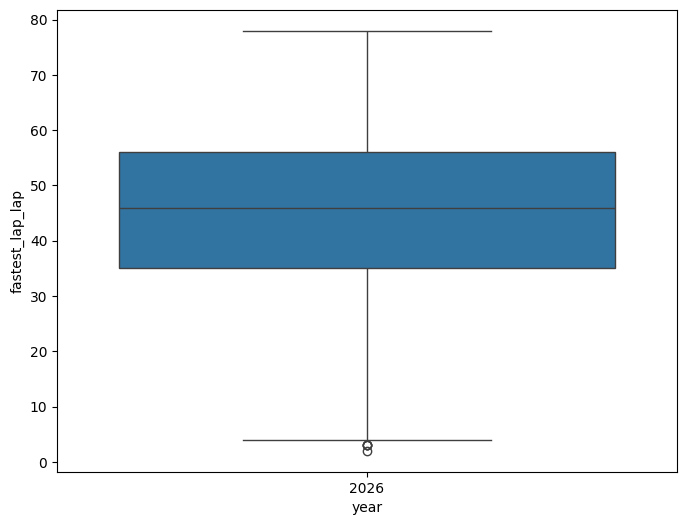

In [54]:
query = "SELECT r.year, r.official_name, rd.fastest_lap_lap FROM race_data AS rd INNER JOIN race AS r ON rd.race_id = r.id WHERE rd.fastest_lap_lap IS NOT NULL AND year = 2026 ORDER BY year DESC"
box_plot(query, "year", "fastest_lap_lap")

        id  total_championship_wins
0   brazil                        0
1   brazil                        0
2   brazil                        3
3   brazil                        0
4   brazil                        0
5   brazil                        0
6   brazil                        0
7   brazil                        0
8   brazil                        0
9   brazil                        2
10  brazil                        0
11  brazil                        0
12  brazil                        0
13  brazil                        0
14  brazil                        0
15  brazil                        0
16  brazil                        0
17  brazil                        0
18  brazil                        0
19  brazil                        0
20  brazil                        0
21  brazil                        0
22  brazil                        0
23  brazil                        3
24  brazil                        0
25  brazil                        0
26  brazil                  

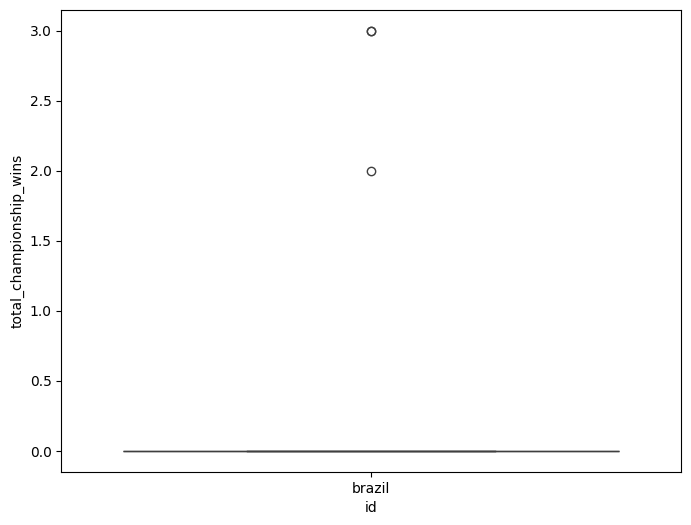

In [63]:
query = "SELECT c.id, d.total_championship_wins FROM driver AS d INNER JOIN country AS c on d.country_of_birth_country_id = c.id WHERE c.id = 'brazil'"
box_plot(query, "id", "total_championship_wins")